In [14]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import pystormtracker as pst
import cartopy.crs as ccrs
import importlib
import stormtracker as st
importlib.reload(st)  # pick up edits in stormtracker.py without restarting the kernel

<module 'stormtracker' from '/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/PyStormTracker/stormtracker.py'>

In [15]:
DATA_DIR = '/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/data'
INPUT_FILE = f'{DATA_DIR}/vo_6h_dec_2013.nc'          # ERA5 pressure levels, 6 h, 0.25°
SAMPLE_FILE = f'{DATA_DIR}/vars_6h_dec_2013.nc'  # ERA5 single levels (t2m, msl, u10, v10, precipitation)
OUT_NAME = 'json/tracks_dec_2013'

# format (west, east, south, north) in degrees
REGION = (-80, 20, 30, 80)   # smaller region for tracking, limited by the domain, 10 deg smaller
DOMAIN = (-90, 30, 20, 90)   # tracking domain (region + buffer), limited by the downloaded data
transformation = ccrs.PlateCarree()  # coordinate transformation for plotting

taper_points = 10
resolution = 0.25
taper_region = (DOMAIN[0] + taper_points * resolution, DOMAIN[1] - taper_points * resolution, DOMAIN[2] + taper_points * resolution, DOMAIN[3] - taper_points * resolution)  # tapering region in degrees

BOXES = ['Domain', 'Region', 'Taper region']


/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


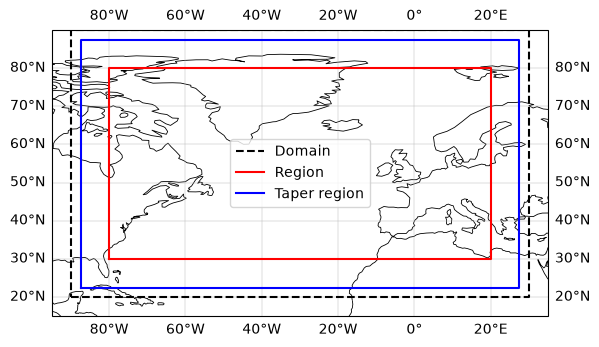

In [16]:
#plot region

fig, ax = plt.subplots( subplot_kw={'projection': transformation})

ax.set_extent([DOMAIN[0] - 5, DOMAIN[1] + 5, DOMAIN[2] - 5, DOMAIN[3]], crs=transformation)
ax.coastlines(linewidth=0.6)
ax.gridlines(draw_labels=True, linewidth=0.3)

for box, style in ((DOMAIN, dict(color="k", linestyle="--")), (REGION, dict(color="red")), (taper_region, dict(color="blue", linestyle="-"))):
    # densify the edges so they follow parallels/meridians in the projection
    lo = np.linspace(box[0], box[1], 100)
    la = np.linspace(box[2], box[3], 100)
    xs = np.concatenate([lo, np.full(100, box[1]), lo[::-1], np.full(100, box[0])])
    ys = np.concatenate([np.full(100, box[2]), la, np.full(100, box[3]), la[::-1]])

    ax.plot(xs, ys, lw=1.5, transform=transformation, **style,label=f"{BOXES.pop(0)}")

plt.legend()

In [17]:
vo = st.prepare_tracking_field(INPUT_FILE, variable='vo', level=850, domain=DOMAIN)
time_name = 'valid_time' if 'valid_time' in vo.coords else 'time'
TIME_RANGE = (vo[time_name].values[0], vo[time_name].values[-1])
vo

<xarray.Dataset> Size: 67MB
Dimensions:     (valid_time: 124, latitude: 281, longitude: 481)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 2013-12-01 ... 2013-12-31T18...
  * latitude    (latitude) float64 2kB 90.0 89.75 89.5 89.25 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 4kB -90.0 -89.75 -89.5 ... 29.5 29.75 30.0
Data variables:
    vo          (valid_time, latitude, longitude) float32 67MB ...

In [18]:
raw_tracks = st.hodges_tracker(
    vo,
    output_file_name=OUT_NAME + '_raw',   # raw tracks are saved too, so the tracker need not be re-run
    track_variable='vo',
    lmin=5, lmax=42,
    taper_points=10,
    object_threshold=1e-5,
    min_object_grid_points=18,
    exclude_boundary_extrema=True,
    min_track_points=4,
)
print(f'{len(raw_tracks)} raw tracks, {len(raw_tracks.lats)} track points')

570 raw tracks, 4862 track points


In [19]:
tracks, summary, points = st.postprocess_tracks(
    raw_tracks,
    region=REGION,
    domain=DOMAIN,
    time_range=TIME_RANGE,
    region_criterion='passes',
    min_points_in_region=8,
    rsplice_min_points=8,                     # >= 48 h at 6 h
    rsplice_max_points=None,
    rsplice_distance_degrees=10.0,            # genesis -> lysis >= 10 degrees
    rsplice_distance_mode='endpoint',
    rsplice_cadence=np.timedelta64(6, 'h'),   # ERA5 time step
    edge_buffer_deg=5,
    max_frac_at_edge=0.25,
    min_peak=None,
    drop_time_truncated=False,
)

In [20]:

st.filter_report(summary)

raw tracks: 570, kept: 75


,removed_by_this_criterion,removed_only_by_this_criterion
rsplice,439,39
region,453,36
edge,182,3
peak,0,0
time,0,0


In [21]:
summary[summary['keep']][['track_id', 'start_time', 'end_time', 'duration_h', 'n_in_region',
                          'rsplice_points', 'rsplice_displacement_deg', 'path_km',
                          'vo_peak', 'time_peak', 'lat_peak', 'lon_peak',
                          'starts_at_first_frame', 'ends_at_last_frame']]

,track_id,start_time,end_time,duration_h,n_in_region,rsplice_points,rsplice_displacement_deg,path_km,vo_peak,time_peak,lat_peak,lon_peak,starts_at_first_frame,ends_at_last_frame
1,2,2013-12-15 06:00:00,2013-12-17 12:00:00,54.0,10,10,15.266519,3649.064271,0.000263,2013-12-15 18:00:00,63.25,-9.25,False,False
4,8,2013-12-13 18:00:00,2013-12-16 00:00:00,54.0,10,10,29.970633,4170.572290,0.000223,2013-12-15 00:00:00,64.50,-7.00,False,False
10,20,2013-12-15 18:00:00,2013-12-20 06:00:00,108.0,16,19,22.750000,6320.407419,0.000186,2013-12-18 18:00:00,71.00,-18.50,False,False
13,27,2013-12-01 00:00:00,2013-12-03 00:00:00,48.0,9,9,13.182657,3702.447489,0.000076,2013-12-01 12:00:00,66.25,-49.75,True,False
14,30,2013-12-01 00:00:00,2013-12-09 00:00:00,192.0,32,33,15.128455,2816.683407,0.000169,2013-12-04 06:00:00,33.25,-28.50,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,1699,2013-12-18 00:00:00,2013-12-20 12:00:00,60.0,9,11,11.645446,3232.169343,0.000074,2013-12-18 00:00:00,69.75,-53.75,False,False
547,1707,2013-12-22 12:00:00,2013-12-24 12:00:00,48.0,8,9,15.117373,4873.204034,0.000158,2013-12-23 00:00:00,60.75,-40.25,False,False
550,1714,2013-12-20 00:00:00,2013-12-22 06:00:00,54.0,10,10,22.211505,2872.941564,0.000043,2013-12-20 00:00:00,47.00,-63.75,False,False
552,1718,2013-12-18 12:00:00,2013-12-21 18:00:00,78.0,14,14,28.721025,5668.513795,0.000137,2013-12-20 12:00:00,57.50,-15.75,False,False


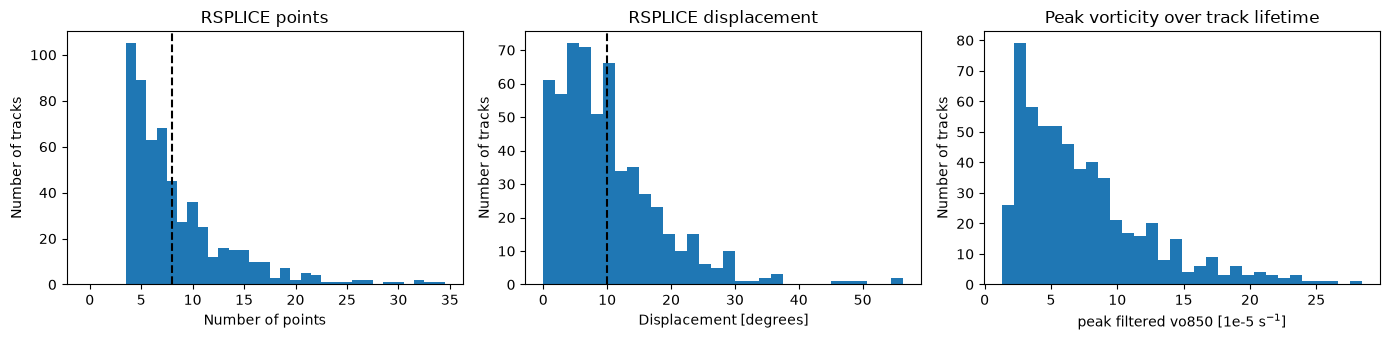

In [22]:
scale= "linear"

fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
axs[0].set_xscale(scale)
axs[0].set_yscale(scale)
axs[0].hist(summary['rsplice_points'], bins=np.arange(0, summary['rsplice_points'].max() + 2) - 0.5)
axs[0].axvline(8, color='k', ls='--')
axs[0].set_xlabel('Number of points')
axs[0].set_title('RSPLICE points')


axs[1].set_xscale(scale)
axs[1].set_yscale(scale)
axs[1].hist(summary['rsplice_displacement_deg'], bins=30)
axs[1].axvline(10, color='k', ls='--')
axs[1].set_xlabel('Displacement [degrees]')
axs[1].set_title('RSPLICE displacement')

axs[2].set_xscale(scale)
axs[2].set_yscale(scale)
axs[2].hist(summary['vo_peak'] * 1e5, bins=30)
axs[2].set_xlabel('peak filtered vo850 [1e-5 s$^{-1}$]')
axs[2].set_title('Peak vorticity over track lifetime')
for ax in axs: ax.set_ylabel('Number of tracks')

plt.tight_layout()

/var/folders/t0/dsmc290j5355qf2rn298qwb40000gn/T/ipykernel_70571/2389173447.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


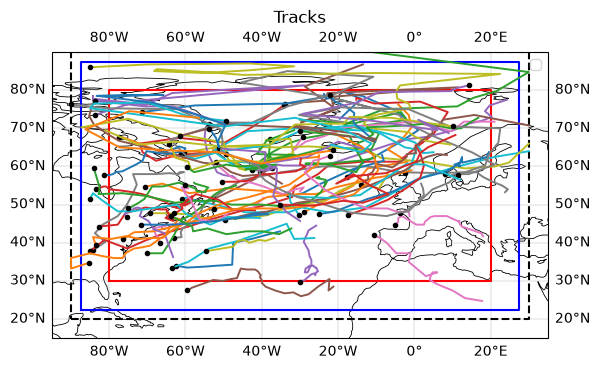

In [23]:
fig, ax = plt.subplots( subplot_kw={'projection': transformation})

ax.set_extent([DOMAIN[0] - 5, DOMAIN[1] + 5, DOMAIN[2] - 5, DOMAIN[3]], crs=transformation)
ax.coastlines(linewidth=0.6)
ax.gridlines(draw_labels=True, linewidth=0.3)

for box, style in ((DOMAIN, dict(color="k", linestyle="--")), (REGION, dict(color="red")), (taper_region, dict(color="blue", linestyle="-"))):
    # densify the edges so they follow parallels/meridians in the projection
    lo = np.linspace(box[0], box[1], 100)
    la = np.linspace(box[2], box[3], 100)
    xs = np.concatenate([lo, np.full(100, box[1]), lo[::-1], np.full(100, box[0])])
    ys = np.concatenate([np.full(100, box[2]), la, np.full(100, box[3]), la[::-1]])

    ax.plot(xs, ys, lw=1.5, transform=transformation, **style)

keep = None if summary is None else dict(zip(summary["track_id"], summary["keep"]))
for tr in tracks:
    kept = True if keep is None else keep.get(tr.track_id, True)
    if kept:
        ax.plot(tr.lons, tr.lats, "-", lw=1.4, transform=transformation)
        ax.plot(tr.lons[0], tr.lats[0], "k.", ms=6, transform=transformation)
    else:
        ax.plot(tr.lons, tr.lats, "-", color="0.75", lw=0.8, transform=transformation, zorder=0)
ax.set_title("Tracks")

plt.legend()

In [24]:
active_time = pd.Timestamp("2013-12-05T18:00")

kept = summary[summary['keep']]
active = kept[(kept['start_time'] <= active_time) & (kept['end_time'] >= active_time)]
active_ids = active['track_id'].values
print(f"Active tracks at {active_time}: {len(active_ids)}")


Active tracks at 2013-12-05 18:00:00: 11


/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


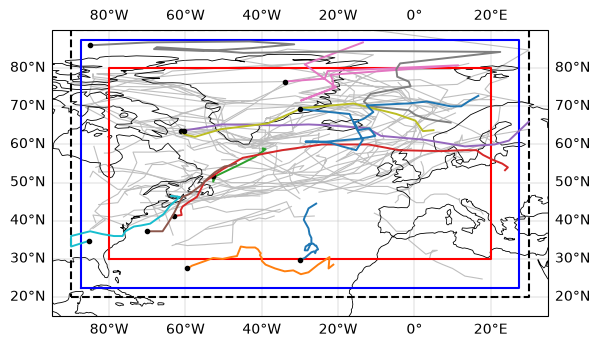

In [25]:
fig, ax = plt.subplots( subplot_kw={'projection': transformation})

ax.set_extent([DOMAIN[0] - 5, DOMAIN[1] + 5, DOMAIN[2] - 5, DOMAIN[3]], crs=transformation)
ax.coastlines(linewidth=0.6)
ax.gridlines(draw_labels=True, linewidth=0.3)

for box, style in ((DOMAIN, dict(color="k", linestyle="--")), (REGION, dict(color="red")), (taper_region, dict(color="blue", linestyle="-"))):
    # densify the edges so they follow parallels/meridians in the projection
    lo = np.linspace(box[0], box[1], 100)
    la = np.linspace(box[2], box[3], 100)
    xs = np.concatenate([lo, np.full(100, box[1]), lo[::-1], np.full(100, box[0])])
    ys = np.concatenate([np.full(100, box[2]), la, np.full(100, box[3]), la[::-1]])

    ax.plot(xs, ys, lw=1.5, transform=transformation, **style)

for tr in tracks:
    if tr.track_id in active_ids:
        ax.plot(tr.lons, tr.lats, "-", lw=1.4, transform=transformation)
        ax.plot(tr.lons[0], tr.lats[0], "k.", ms=6, transform=transformation)
    else:
        ax.plot(tr.lons, tr.lats, "-", color="0.75", lw=0.8, transform=transformation, zorder=0)

In [26]:
track_points, track_summary = st.track_statistics(
    tracks, SAMPLE_FILE, radius_km=500, strict_time=False,
)
track_summary

,track_id,t_min,t_max,msl_min,ws_max,ws_mean,vo_max,n_points,start_time,end_time,duration_h,lat_genesis,lon_genesis,lat_lysis,lon_lysis,time_of_vo_max
0,2,238.620041,284.086243,94537.6250,34.409683,12.240835,0.000263,10,2013-12-15 06:00:00,2013-12-17 12:00:00,54.0,57.25,-17.75,72.50,-19.50,2013-12-15 18:00:00
1,8,255.398621,289.755005,95239.1250,29.716665,14.362556,0.000223,10,2013-12-13 18:00:00,2013-12-16 00:00:00,54.0,48.00,-29.00,76.25,-4.25,2013-12-15 00:00:00
2,20,236.141525,281.722046,94782.1875,26.089125,9.162148,0.000186,19,2013-12-15 18:00:00,2013-12-20 06:00:00,108.0,67.25,-37.75,90.00,-11.25,2013-12-18 18:00:00
3,27,227.347168,271.725220,99717.0625,15.015562,5.821177,0.000076,9,2013-12-01 00:00:00,2013-12-03 00:00:00,48.0,76.00,-34.25,64.00,-51.00,2013-12-01 12:00:00
4,30,286.965942,296.069824,99251.0625,24.342810,10.821986,0.000169,33,2013-12-01 00:00:00,2013-12-09 00:00:00,192.0,29.75,-30.00,44.50,-25.75,2013-12-04 06:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,1699,224.607407,268.307190,96328.3750,27.952551,5.996841,0.000074,11,2013-12-18 00:00:00,2013-12-20 12:00:00,60.0,69.75,-53.75,78.50,-83.25,2013-12-18 00:00:00
71,1707,227.528305,279.624512,95815.1875,24.210091,9.363890,0.000158,9,2013-12-22 12:00:00,2013-12-24 12:00:00,48.0,64.25,-21.25,72.75,-56.50,2013-12-23 00:00:00
72,1714,249.806625,292.174377,100465.3125,17.170918,7.876884,0.000043,10,2013-12-20 00:00:00,2013-12-22 06:00:00,54.0,47.00,-63.75,43.75,-32.25,2013-12-20 00:00:00
73,1718,259.160614,286.518311,95930.4375,20.731878,13.574949,0.000137,14,2013-12-18 12:00:00,2013-12-21 18:00:00,78.0,50.00,-35.25,68.25,10.75,2013-12-20 12:00:00


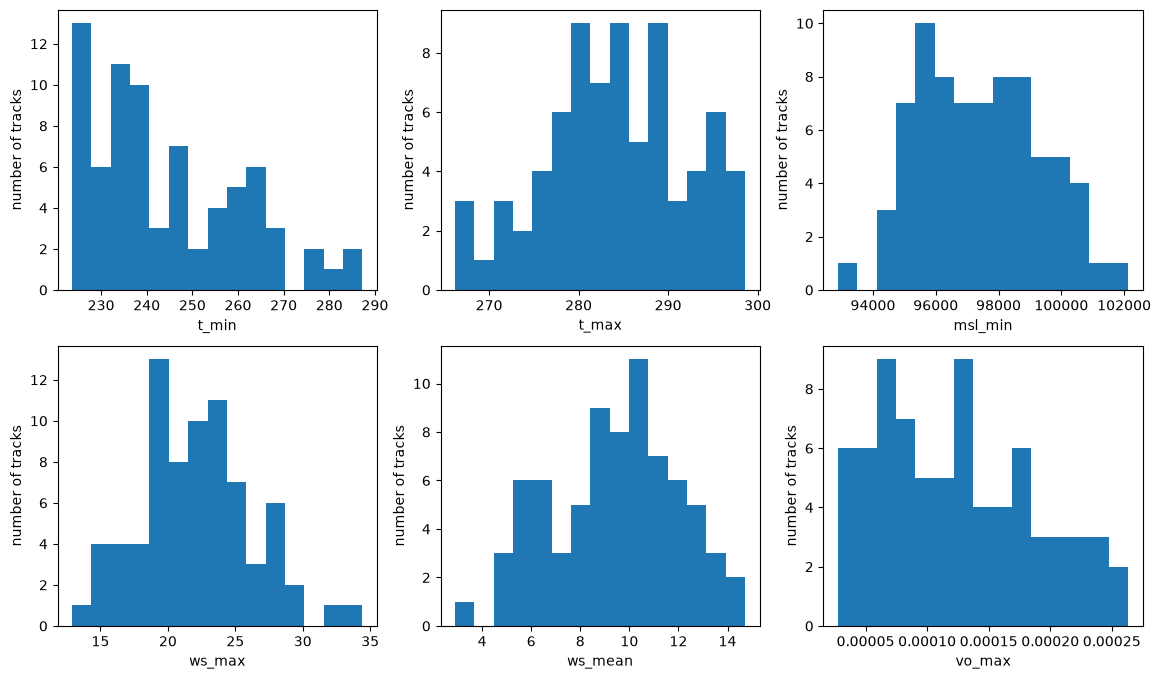

In [32]:
#distribution of track statistics

variables = ['t_min', 't_max', 'msl_min', 'ws_max', 'ws_mean', 'vo_max'] 

fig, ax = plt.subplots(2, 3, figsize=(14, 8))

ax = ax.flatten()

for i, var in enumerate(variables):
    ax[i].hist(track_summary[var], bins=15)
    ax[i].set_xlabel(var)
    ax[i].set_ylabel('number of tracks')




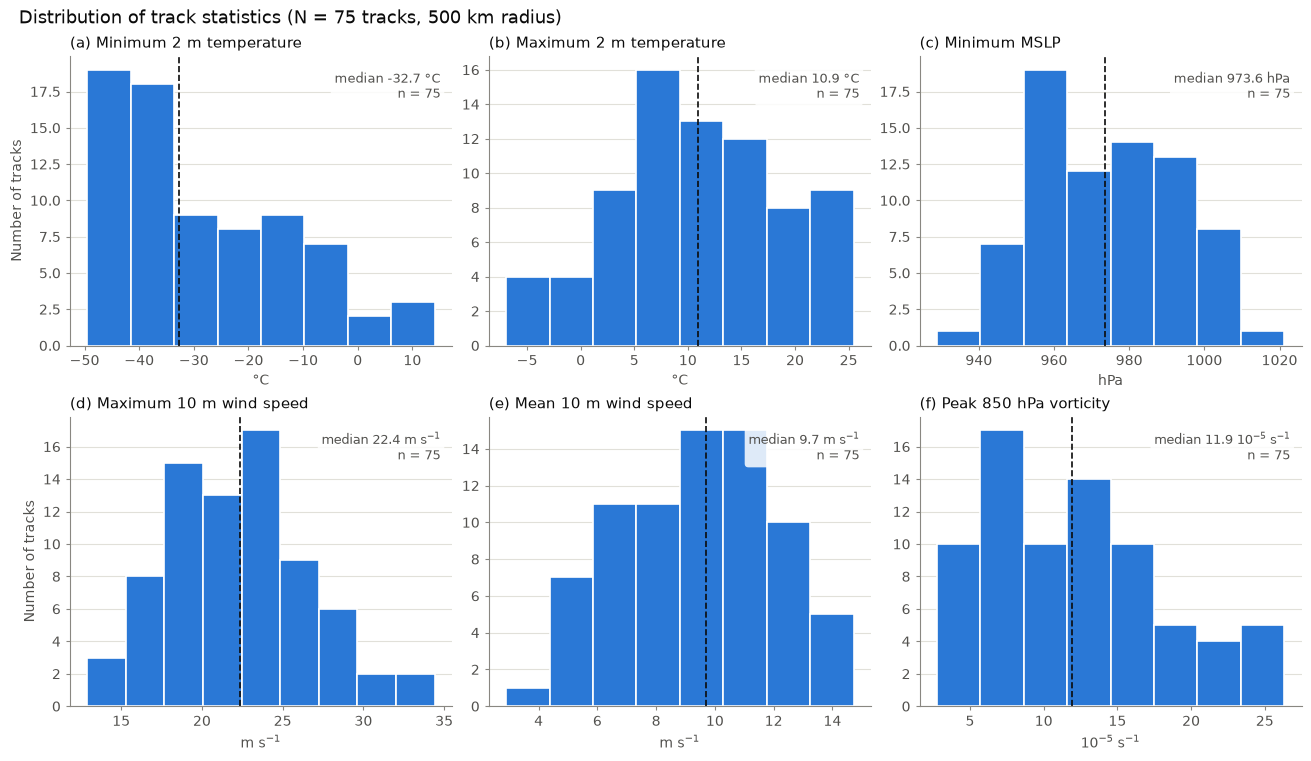

In [33]:
# variable -> (title, unit, conversion from the raw ERA5 units)
PLOT_VARS = {
    "t_min":   ("Minimum 2 m temperature", "°C",                  lambda x: x - 273.15),
    "t_max":   ("Maximum 2 m temperature", "°C",                  lambda x: x - 273.15),
    "msl_min": ("Minimum MSLP",            "hPa",                 lambda x: x / 100),
    "ws_max":  ("Maximum 10 m wind speed", "m s$^{-1}$",          lambda x: x),
    "ws_mean": ("Mean 10 m wind speed",    "m s$^{-1}$",          lambda x: x),
    "vo_max":  ("Peak 850 hPa vorticity",  r"$10^{-5}$ s$^{-1}$", lambda x: x * 1e5),
}

BAR = "#2a78d6"                      # one series -> one colour
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "font.size": 10, "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
})

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), constrained_layout=True)

for i, (ax, (var, (title, unit, conv))) in enumerate(zip(axes.flat, PLOT_VARS.items())):
    x = conv(track_summary[var].dropna().to_numpy())
    ax.hist(x, bins="auto", color=BAR, edgecolor="white", linewidth=1.2, zorder=2)

    med = np.median(x)
    ax.axvline(med, color=INK, lw=1.2, ls="--", zorder=3)
    ax.text(0.97, 0.95, f"median {med:.1f} {unit}\nn = {len(x)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color=INK2,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))

    ax.set_title(f"({chr(97 + i)}) {title}", loc="left", fontsize=11, color=INK)
    ax.set_xlabel(unit)
    if i % 3 == 0:
        ax.set_ylabel("Number of tracks")

    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=3)

fig.suptitle(f"Distribution of track statistics (N = {len(track_summary)} tracks, 500 km radius)",
             fontsize=13, color=INK, x=0.01, ha="left")
fig.savefig("track_stats_hist.png", dpi=300, facecolor="white")